# Creativity in vitro · Pre-processing with MNE - Binary Test Sun/Rest

**Author:** Lina Lopes  **Date:** 2025-06-25  
This notebook converts a single OpenBCI  *raw* CSV recorded with an **OpenBCI Cyton (8 active channels)** into 1 cleaned `RawArray` block, applies standard 10-20 montage, band-pass filtering (0.1–45 Hz + notch 50 Hz), performs quality-control metrics, and exports
per-block HTML reports.


**Pipeline outline**

1. Load raw CSV & unit conversion (counts → µV)
2. Confirm recording constants  
3. Assign montage & verify sensor layout (10-20)  
4. Filtering and crop
5. Signal-noise-ratio and Quality Assurance
6. Reports

> **Key results**  
> * Median SNR improvement: **≈ +17 dB** after filtering & crop  
> * EEG peak amplitude across 8 channels: **mean ±3.6 µV**, max **8.1 µV**  
> * No blocks flagged for excessive variance


In [3]:
from pathlib import Path
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import json

### Configuration dictionary

* `csv_path` Full path to the raw BrainFlow CSV.  
* `raw_dir` Directory for unfiltered `.fif` blocks.  
* `fif_dir` Directory for filtered/cropped `.fif` blocks and QA reports.  
* `ch_order` Canonical 8-channel order used throughout the pipeline.

All hard-coded paths and parameters appear **exactly once** in `CONFIG`;
every subsequent cell references them, guaranteeing consistency.

In [4]:
CONFIG = {
    'csv_path': Path('../bids_dataset/sourcedata/openbci/ses-03/BrainFlow-RAW_2025-06-24_11-31-27_0.csv'),
    'raw_dir' : Path('../bids_dataset/sub-lina/ses-03/eeg'),
    'fif_dir' : Path('../bids_dataset/derivatives/filt_crop/sub-lina/ses-03/eeg/'),
    'qa_dir'  : Path('../bids_dataset/derivatives/qa_reports/sub-lina/ses-03/eeg/'),
    'ch_order': [
        'F3', 'F4', 'C3', 'C4', 'P3',  'P4', 'Pz', 'Oz'],
    'sfreq': 250,
    'duration': 344
}

In [5]:
IMPEDANCE = {
    'units': 'kOhm',
    'channels': ['F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'Pz', 'Oz'],
    'values':  [8, 11, 7, 13, 8, 11, 18, 11],
    'timestamp': '2025-06-24T11:29:00',
    'notes': 'Gel electrodes, OpenBCI GUI test screen'
}

## 1. Inspect raw file structure

The OpenBCI GUI writes **24 columns**:
| Column range | Content                                                     |
| ------------ | ----------------------------------------------------------- |
| 0            | Sample index (frame count)                                  |
| 1–8          | ADS1299 counts (EEG channels 1–8 → F3 to Oz)                |
| 9–11         | Accelerometer (X / Y / Z)                                   |
| 12–14        | Analog inputs (AUX)                                         |
| 15–23        | Miscellaneous (battery level, marker bits, timestamp, etc.) |


In [6]:
csv_path = CONFIG['csv_path']

df_raw=pd.read_csv(csv_path, header=None, sep="\t")
print("dataframe shape:", df_raw.shape)
df_raw.head()

dataframe shape: (98232, 24)


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750758e+09,0.0
1,1.0,-5728.014496,-1678.817174,-23860.062523,-10642.626660,-13004.647255,-2261.102469,-371.597752,11117.176547,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750758e+09,0.0
2,2.0,-5726.114598,-1672.558686,-23851.568860,-10654.964823,-13010.212840,-2269.842001,-377.029225,11100.613904,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750758e+09,0.0
3,3.0,-5688.206039,-1663.573285,-23803.333795,-10623.314753,-12982.608435,-2236.895530,-360.623045,11105.553640,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750758e+09,0.0
4,4.0,-5684.763871,-1681.655846,-23798.505819,-10610.283686,-12976.729927,-2226.211396,-364.199324,11110.068692,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750758e+09,0.0


### Detecting Trigger Events from D12 (Button Press) with Debounce Logic

In this step, we detect the moments when a physical push button connected to the D12 digital input of the OpenBCI Cyton board was pressed.

- The D12 channel is recorded in column 15 of the raw CSV file.
- By default, the digital line is HIGH (`1`) and goes LOW (`0`) when the button is pressed.
- We detect transitions from `1 → 0` to identify the **exact moment** the button was activated.
- However, button presses can last multiple samples and sometimes cause brief digital fluctuations.
- To avoid false positives, we apply a **debounce filter** of 2.5 minutes (18750 samples), ensuring only one trigger is detected per recording block.

We then visualize the EEG signal with vertical red dashed lines marking each detected trigger. This helps confirm that the detected trigger points align with the expected start of each recording block.


In [7]:
# Show columns with less than 10 unique values
trigger_candidates = []

print("🔍 Columns with few unique values:")
for col in df_raw.columns:
    unique_vals = df_raw[col].dropna().unique()
    if len(unique_vals) <= 10:
        print(f"- {col}: {unique_vals}")
        trigger_candidates.append(col)

# Show columns that change value (not constant)
print("\n🔁 Columns that change value:")
for col in trigger_candidates:
    series = df_raw[col].dropna()
    if series.nunique() > 1:
        print(f"- {col}: changed {series.nunique()} times")

# Show columns that have exactly two values (0 and 1, for example)
print("\n✅ Columns with exactly two values:")
for col in trigger_candidates:
    vals = set(df_raw[col].dropna().unique())
    if vals == {0.0, 1.0} or vals == {1.0, 0.0}:
        print(f"- {col} could be a digital trigger (0 ↔ 1)")


🔍 Columns with few unique values:
- 9: [0.]
- 10: [0.]
- 11: [0.]
- 12: [193.]
- 13: [0.]
- 14: [1. 0.]
- 15: [1.]
- 16: [0.]
- 17: [0.]
- 18: [1.]
- 19: [1. 0.]
- 20: [256.]
- 21: [1.]
- 23: [0.]

🔁 Columns that change value:
- 14: changed 2 times
- 19: changed 2 times

✅ Columns with exactly two values:
- 14 could be a digital trigger (0 ↔ 1)
- 19 could be a digital trigger (0 ↔ 1)


In [8]:
# Initial settings
sfreq = CONFIG['sfreq']  # Hz
col_d12 = 14  # D12 confirmed in column 14
min_spacing = int(sfreq * 60 * 2.5)  # 2.5 minutes

# D12 series: 1 = HIGH (released), 0 = LOW (pressed)
d12_series = df_raw.iloc[:, col_d12].fillna(1).astype(int)

# Detect 1 → 0 transitions (button pressed)
trigger_events = (d12_series.shift(1) == 1) & (d12_series == 0)
trigger_indices = df_raw[trigger_events].index.tolist()
print(f"Total transitions detected (1 → 0): {len(trigger_indices)}")

# Apply debounce: only consider new event if 2.5 minutes passed since last one
filtered_indices_final = []
last_idx = -min_spacing

for idx in trigger_indices:
    if idx - last_idx >= min_spacing:
        filtered_indices_final.append(idx)
        last_idx = idx

print(f"Real events after 2.5 minutes debounce: {len(filtered_indices_final)}")
print("Detected trigger indices:")
print(filtered_indices_final)


Total transitions detected (1 → 0): 711
Real events after 2.5 minutes debounce: 1
Detected trigger indices:
[3553]


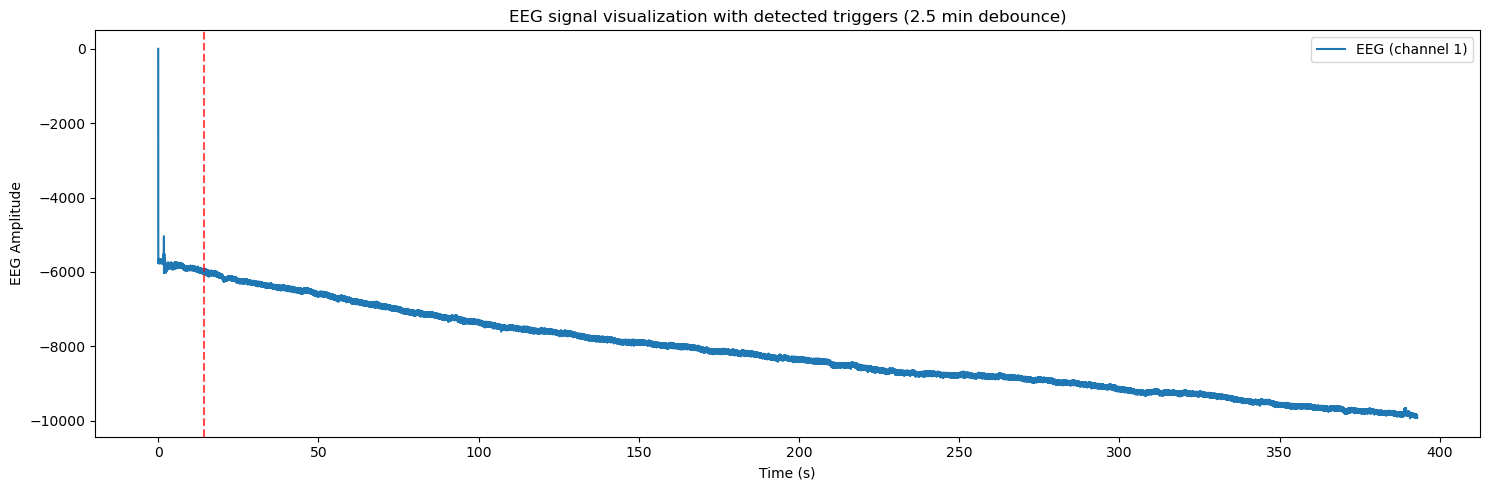

In [9]:
# Choose EEG channel for visualization
eeg_channel_col = 1  # can adjust to another channel if preferred
eeg_signal = df_raw.iloc[:, eeg_channel_col].astype(float)

# Relative time in seconds
sfreq = CONFIG['sfreq']
time_sec = df_raw.index / sfreq

# Convert final trigger indices to time (seconds)
trigger_times_sec = [idx / sfreq for idx in filtered_indices_final]

# Plot
plt.figure(figsize=(15, 5))
plt.plot(time_sec, eeg_signal, label=f'EEG (channel {eeg_channel_col})')

# Red vertical lines at triggers
for t in trigger_times_sec:
    plt.axvline(t, color='red', linestyle='--', alpha=0.7)

plt.title("EEG signal visualization with detected triggers (2.5 min debounce)")
plt.xlabel("Time (s)")
plt.ylabel("EEG Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


### Cleaning Raw Data: Dropping Unused Columns and Preserving D12

In this step, we remove unnecessary columns from the raw EEG dataset exported by the OpenBCI GUI.

- The original CSV contains extra columns such as auxiliary channels, digital channels, timestamps, and markers.
- We drop irrelevant columns (e.g., unused auxiliary or digital lines) while **preserving column 22**, which contains the digital input from **D12** — used to detect button presses marking the start of each recording block.
- After dropping, we rename the remaining columns using standard EEG channel labels along with `D12`, `timestamp`, and `marker`.
- We also compute a new column `time_sec` to represent the relative time from the beginning of the recording, which is useful for aligning events.

This cleaned version of the data is used for trigger detection, visualization, and conversion to BIDS format.


In [10]:
cols_to_keep = [0] + list(range(1, 9)) + [14, 22]
df_raw = df_raw.iloc[:, cols_to_keep]

eeg_labels = CONFIG["ch_order"]
col_names = ["sample_index"] + eeg_labels + ["D12", "timestamp"]
df_raw.columns = col_names

df_raw["time_sec"] = df_raw["timestamp"] - df_raw["timestamp"].iloc[0]

In [11]:
sfreq = CONFIG['sfreq']  # Hz, or the actual frequency used in recording
n_samples = len(df_raw)

duration_seconds = n_samples / sfreq
print(f"⏱️ Total recording duration: {duration_seconds:.2f} seconds")


⏱️ Total recording duration: 392.93 seconds


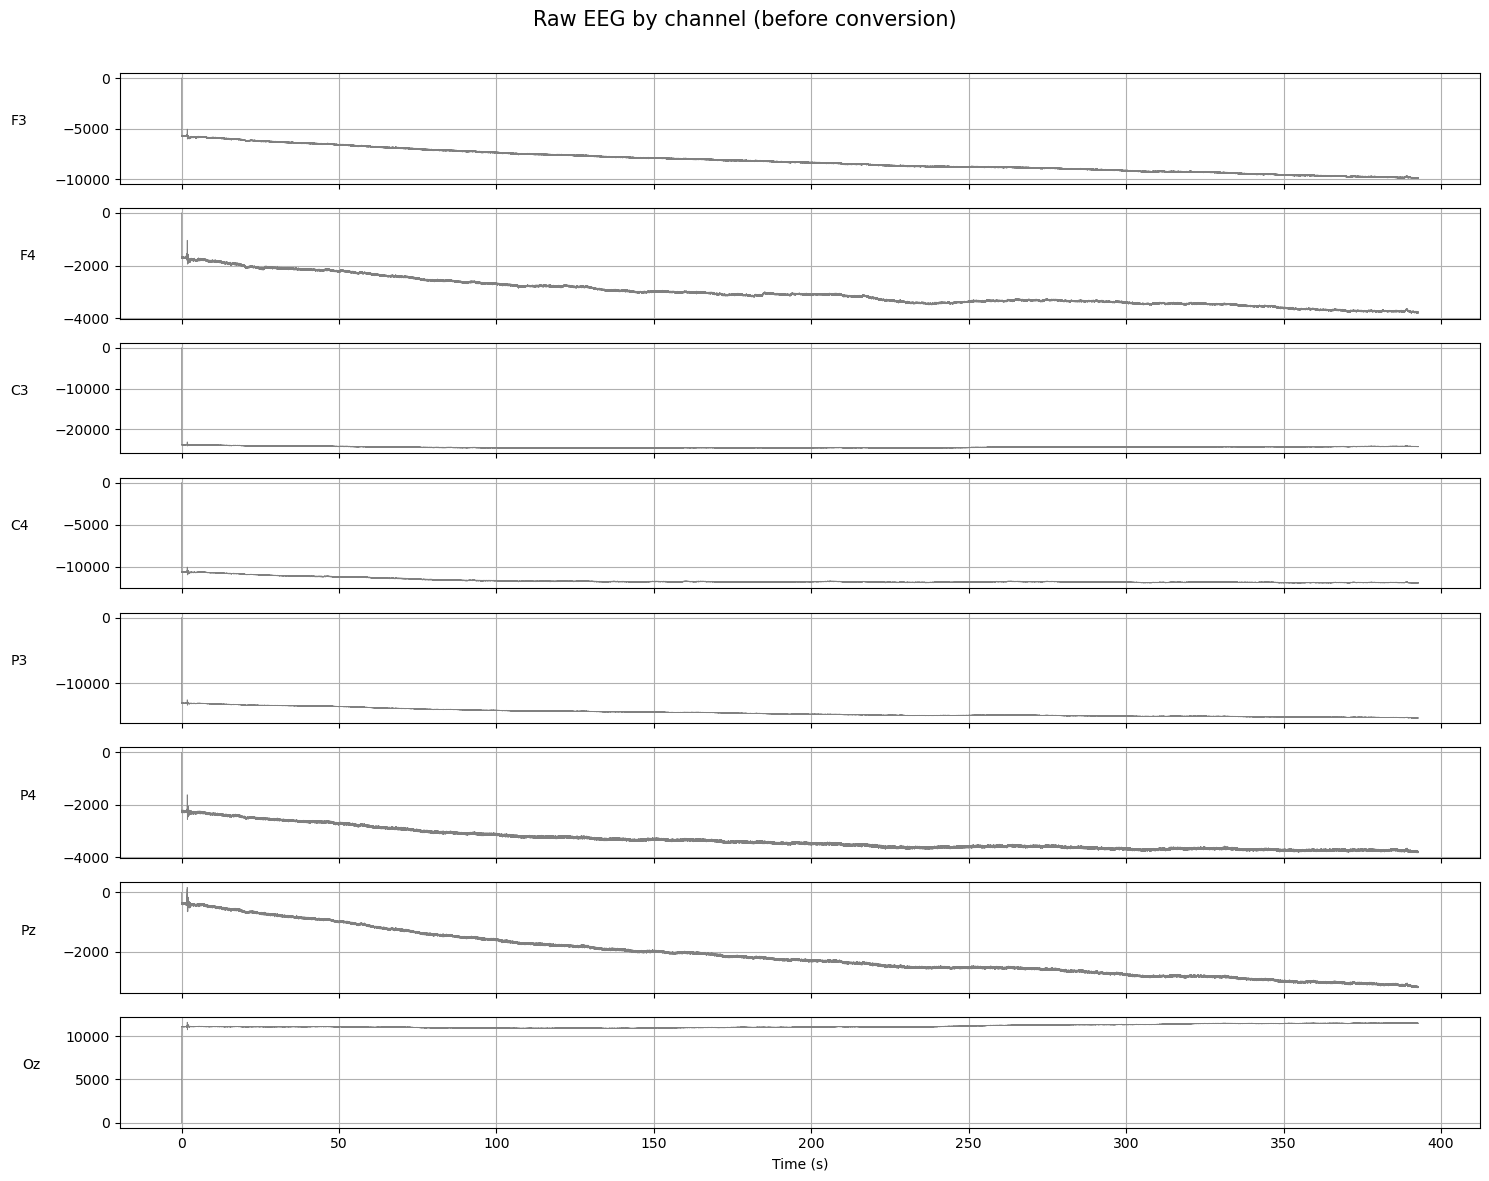

In [12]:
# Parameters
sfreq = CONFIG['sfreq']
eeg_cols = CONFIG["ch_order"]

# Time axis
if "time_sec" in df_raw.columns:
    times = df_raw["time_sec"].to_numpy()
else:
    times = np.arange(len(df_raw)) / sfreq

# Plot raw signal
fig, axes = plt.subplots(len(eeg_cols), 1, figsize=(15, 12), sharex=True)

for i, ch in enumerate(eeg_cols):
    axes[i].plot(times, df_raw[ch], color='gray', linewidth=0.5)
    axes[i].set_ylabel(ch, rotation=0, labelpad=25)
    axes[i].grid(True)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Raw EEG by channel (before conversion)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 2. Confirm recording constants

Before we convert the raw EEG data to microvolts, we verify and prepare the constants needed for all future steps.

1. **Sampling rate assumption**  
   This dataset was recorded with the Cyton board **without Daisy**, so the `sample_index` increments by 1, corresponding to a fixed  
   **sampling rate of 250 Hz** (Nyquist = 125 Hz).  
   We skip auto-detection and assume this constant throughout.

2. **Unit scale: counts → µV**  
   The ADS1299 outputs 24-bit integer values representing differential voltage measurements.  
   OpenBCI’s firmware applies a built-in gain and scaling factor to convert those counts to microvolts.

   The documented scale is:

   $$
   \text{1 count} \approx 0.02235\,\mu\text{V}
   $$

   We will use this constant (`UV_PER_COUNT`) for all EEG conversions.  
   Note: the raw values are large integers (±10⁴–10⁵) and will be scaled accordingly.

Below, we perform two steps:
- First, we **diagnose and remove rows with NaN values** in EEG channels (if any)
- Then, we **convert the clean signal to µV** and print the count/amplitude range


In [13]:
eeg_cols = CONFIG["ch_order"]  # ['F3', 'F4', ..., 'Oz']

# Identify rows with at least one NaN in EEG channels
nan_mask = df_raw[eeg_cols].isna()
nan_rows = nan_mask.any(axis=1)
nan_indices = df_raw.index[nan_rows].to_list()

# Threshold for direct removal without interpolation
nan_count = len(nan_indices)
total_rows = len(df_raw)
nan_threshold = 20  # you can adjust this value

print(f"🔍 Total rows with NaN: {nan_count} out of {total_rows}")

if nan_count <= nan_threshold:
    print("✅ Number of NaNs below threshold. Removing these rows.")
    df_clean = df_raw.drop(index=nan_indices).reset_index(drop=True)
else:
    raise ValueError("⚠️ Number of NaNs exceeds threshold. Consider interpolating or reviewing the data.")


🔍 Total rows with NaN: 0 out of 98232
✅ Number of NaNs below threshold. Removing these rows.


In [14]:
# Conversion constant: 0.02235 µV per count (documented)
UV_PER_COUNT = 0.02235

# Extract raw data matrix from EEG channels
counts = df_clean[eeg_cols].to_numpy(dtype=float)

# Convert to microvolts
amplitudes_uV = counts * UV_PER_COUNT

# Show value ranges
print(f"🔢 Raw counts range: {counts.min():.0f} – {counts.max():.0f}")
print(f"⚡ Converted amplitude range: {amplitudes_uV.min():.1f} – {amplitudes_uV.max():.1f} µV")


🔢 Raw counts range: -24697 – 11627
⚡ Converted amplitude range: -552.0 – 259.9 µV


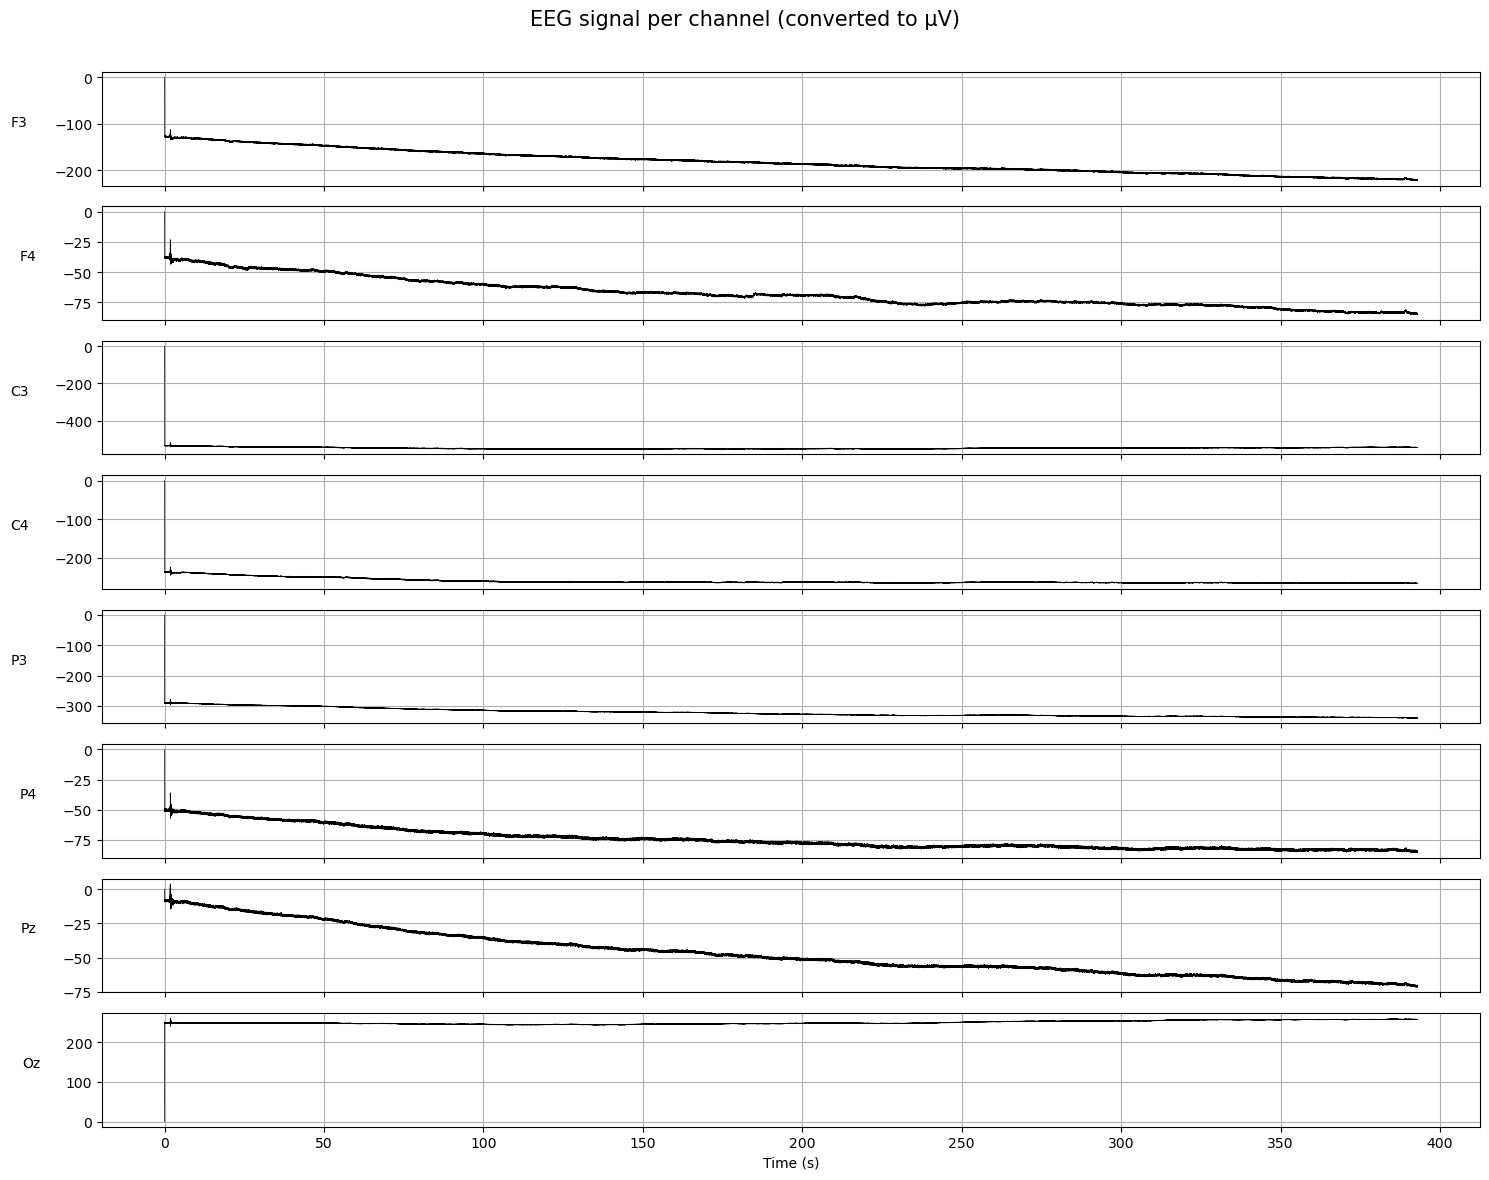

In [15]:
# Get time axis in seconds (based on sampling rate and number of samples)
SFREQ = CONFIG['sfreq']  # Hz (assumed)
times = np.arange(len(df_clean)) / sfreq

# Convert the cleaned EEG channels to µV
eeg_uV = df_clean[eeg_cols] * UV_PER_COUNT

# Plot the 8 channels as separate subplots
fig, axes = plt.subplots(len(eeg_cols), 1, figsize=(15, 12), sharex=True)

for i, ch in enumerate(eeg_cols):
    axes[i].plot(times, eeg_uV[ch], color='black', linewidth=0.5)
    axes[i].set_ylabel(ch, rotation=0, labelpad=25)
    axes[i].grid(True)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("EEG signal per channel (converted to µV)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 3. Build Raw object from full session

In this binary protocol, we recorded one single continuous EEG block.  
This step creates a clean `RawArray` object and saves it as a `.fif` file with proper BIDS metadata.

Steps:
1. **Select EEG + marker columns**  
2. Convert ADS1299 **counts → µV** (scale = 0.02235)  
3. Append the marker (`D12`) as a `stim` channel  
4. Create an MNE `RawArray` with standard 10-20 montage  
5. Save to `.fif` + `.json` under `ses-third`, with proper BIDS naming


In [16]:
# DataFrame → RawArray → .fif + .json

out_dir = CONFIG['raw_dir']
out_dir.mkdir(exist_ok=True)

# EEG and marker setup
eeg_cols   = CONFIG['ch_order']
marker_col = "D12"
mne_names  = eeg_cols + ["stim"]
ch_types   = ["eeg"] * 8 + ["stim"]

# --- 1. Get EEG + marker
counts = df_clean[eeg_cols].to_numpy(dtype=float).T
stim   = df_clean[[marker_col]].to_numpy(dtype=float).T

# --- 2. Convert counts to Volts
data_volts = amplitudes_uV.T * 1e-6
data       = np.vstack([data_volts, stim])

# --- 3. Create MNE RawArray
info = mne.create_info(mne_names, sfreq=SFREQ, ch_types=ch_types)
raw  = mne.io.RawArray(data, info, verbose=False)
raw.set_montage("standard_1020")
raw.set_eeg_reference('average', projection=True)

# --- 4. Add metadata
raw.info['subject_info'] = dict(
    id=1,
    first_name='Lina',
    birthday=datetime.date(1985, 7, 1)
)
raw.info['line_freq']    = 50
raw.info['experimenter'] = 'Lina Lopes'
raw.info['description']  = 'Creativity in vitro – 24/06/2025'

# --- 5. Save .fif and .json
bids_name = "sub-lina_ses-03_task-sunimagery_run-01_eeg"
fname     = out_dir / f"{bids_name}.fif"
raw.save(fname, overwrite=True, verbose=False)
print("✅ Saved:", fname.name)

json_metadata = {
    "TaskName": "sunimagery",
    "InstitutionName": "Creativity in vitro",
    "SamplingFrequency": raw.info["sfreq"],
    "EEGReference": "average",
    "PowerLineFrequency": 50,
    "EEGChannelCount": 8,
    "SoftwareFilters": {
        "HighPass": 1.0,
        "LowPass": 45.0,
        "Notch": [50]
    },
    "CapManufacturer": "OpenBCI"
}

json_path = out_dir / f"{bids_name}.json"
with open(json_path, "w") as f:
    json.dump(json_metadata, f, indent=4)
print("🧾 Metadata saved:", json_path.name)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
✅ Saved: sub-lina_ses-03_task-sunimagery_run-01_eeg.fif
🧾 Metadata saved: sub-lina_ses-03_task-sunimagery_run-01_eeg.json


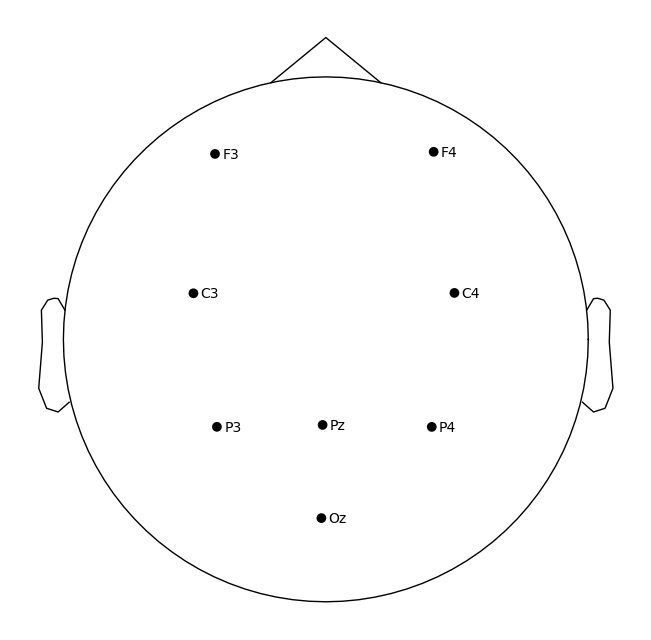

Text(0.5, 0.98, 'EEG Sensor Positions (2D)')

<Figure size 640x480 with 0 Axes>

In [17]:
# 2D Topomap
fig = raw.plot_sensors(kind="topomap", show_names=True, sphere=0.09)
plt.suptitle("EEG Sensor Positions (2D)", fontsize=14)


In [18]:
# 3-D sensor positions – no head surface, no trans needed
mne.viz.plot_alignment(
    raw.info,
    coord_frame="head",   # default is 'head'; keeps numbers in cm
    eeg="original",       # draw EEG sensors as stored
    dig=True,             # include digitization / montage points
    show_axes=True,
    surfaces=[],          # <-- remove 'head' surface => no trans required
    verbose=False
)


## 4. Linear filtering & cropping (binary block)

In this step we apply **zero-phase FIR filtering** to the full binary session  
and **crop the signal based on the trigger** from the `D12` button.

### Filtering:
- **Band-pass 0.1–45 Hz** (Hamming window, zero-phase FIR)
- **Notch at 50 Hz** (optional: 60 Hz not present in recording)
- Filters are non-causal and symmetric (zero-phase FIR)
- Lowering the high-pass cutoff to **0.1 Hz** preserves slow cortical potentials relevant to resting and imagery states

### Cropping:
- We detect the **first falling edge (1 → 0)** of `D12` (stored in the `stim` channel)
- All data **prior to the trigger** is discarded
- We retain the next **344 seconds of task**, followed by a **3-second baseline**

### Referencing:
- The **average-reference projection** remains stored in `info['projs']`
- It is **not activated yet**, only later before ICA

The result is saved to:
- `*_desc-filtcrop_eeg.fif` → task segment (filtered and cropped)
- `*_desc-baseline_eeg.fif` → 3s baseline after task (filtered)

In [19]:
# Filtering and cropping the single binary EEG block
in_dir  = CONFIG['raw_dir']
out_dir = CONFIG['fif_dir']
out_dir.mkdir(parents=True, exist_ok=True)

# File from previous step (raw continuous block)
f_in = in_dir / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
raw  = mne.io.read_raw_fif(f_in, preload=True, verbose=False)

# --- Filtering
raw.filter(0.1, 45., fir_design="firwin", phase="zero-double")
raw.notch_filter([50], fir_design="firwin", phase="zero-double")

# --- Detect trigger: first falling edge (1 → 0) in 'stim'
d12 = raw.copy().pick_channels(["stim"]).get_data()[0].astype(int)
trigger_sample = None
for i in range(1, len(d12)):
    if d12[i-1] == 1 and d12[i] == 0:
        trigger_sample = i
        break

if trigger_sample is None:
    raise RuntimeError("⚠️ No trigger (1→0) found in stim channel.")

# --- Crop around trigger
sfreq = raw.info['sfreq']
trigger_time = trigger_sample / sfreq
t_task_end = trigger_time + CONFIG['duration']
t_baseline_end = t_task_end + 3.0

if t_baseline_end > raw.times[-1]:
    raise RuntimeError("⚠️ Recording too short for task + baseline.")

raw_task = raw.copy().crop(tmin=trigger_time, tmax=t_task_end)
raw_base = raw.copy().crop(tmin=t_task_end, tmax=t_baseline_end)

# --- Save TASK block
task_name = "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg"
f_task = out_dir / f"{task_name}.fif"
raw_task.save(f_task, overwrite=True)
print("✅ Task block saved:", f_task.name)

json_task = {
    "TaskName": "sunimagery",
    "SamplingFrequency": sfreq,
    "EEGReference": "average",
    "PowerLineFrequency": raw.info.get("line_freq", 50),
    "EEGChannelCount": len([ch for ch in raw.info["chs"] if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH]),
    "SoftwareFilters": {"HighPass": 1.0, "LowPass": 45.0, "Notch": [50]},
    "Description": "Filtered EEG task segment (133s) after trigger.",
    "Authors": ["Lina Lopes"]
}
with open(f_task.with_suffix(".json"), "w") as f:
    json.dump(json_task, f, indent=4)

# --- Save BASELINE block
base_name = "sub-lina_ses-03_task-sunimagery_run-01_desc-baseline_eeg"
f_base = out_dir / f"{base_name}.fif"
raw_base.save(f_base, overwrite=True)
print("✅ Baseline block saved:", f_base.name)

json_base = json_task.copy()
json_base["Description"] = "Filtered EEG baseline segment (final 3s after task)."
with open(f_base.with_suffix(".json"), "w") as f:
    json.dump(json_base, f, indent=4)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 45 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-12 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-12 dB cutoff frequency: 50.62 Hz)
- Filter length: 8251 samples (33.004 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-12 dB cu

[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   8 out of   8 | elapsed:    0.0s finished


In [20]:
filt_crop_dir = CONFIG['fif_dir']
min_duration = CONFIG['duration']

fif_files = sorted(filt_crop_dir.glob("*desc-filtcrop_eeg.fif"))

print(f"Checking {len(fif_files)} files:\n")

for fpath in fif_files:
    raw = mne.io.read_raw_fif(fpath, preload=False, verbose=False)
    duration_sec = raw.n_times / raw.info['sfreq']

    status = "✓ OK" if duration_sec >= min_duration else "⚠️ SHORT"
    print(f"{fpath.name:<70} → {duration_sec:6.2f} s  {status}")


Checking 2 files:

sub-01_ses-third_task-sunimagery_run-01_desc-filtcrop_eeg.fif          → 344.00 s  ✓ OK
sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif           → 344.00 s  ✓ OK


## 5. SNR, signal check

### 5a · Quick SNR check (power ratio)

We approximate SNR as **mean power 1–40 Hz / mean power 55–62 Hz**.

In [21]:
def quick_snr(raw, sig=(1, 45), noi=(40, 62), db=False):
    """
    Median-channel SNR for a Raw object.
    `sig`  = signal band (Hz)
    `noi`  = noise band  (Hz) — will be clipped to Nyquist if needed.
    """
    nyq = raw.info['sfreq'] / 2.0
    noi_high = min(noi[1], nyq - 0.1)        # stay below Nyquist

    psd = raw.compute_psd(
        fmin=sig[0], fmax=noi_high,
        n_fft=int(raw.info['sfreq'] * 2),
        verbose=False
    )
    f = psd.freqs
    p = psd.get_data(picks='eeg')

    sig_pow = p[:, (sig[0] <= f) & (f <= sig[1])].mean(axis=1)
    noi_pow = p[:, (noi[0] <= f) & (f <= noi_high)].mean(axis=1)

    snr = np.median(sig_pow / noi_pow)
    return 10 * np.log10(snr) if db else snr


In [22]:
# Quick SNR check with delta in dB

# File paths
pre_file = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
post_file = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

# Load raw files
raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

# Compute SNR values
snr_pre  = quick_snr(raw_pre,  db=True)
snr_post = quick_snr(raw_post, db=True)
delta_snr = snr_post - snr_pre

# Print results
print("▶︎ File: sunimagery_run-01")
print(f"SNR before filtering : {snr_pre:.2f} dB")
print(f"SNR after  filtering : {snr_post:.2f} dB")
print(f"Δ SNR (post - pre)   : {delta_snr:.2f} dB")


▶︎ File: sunimagery_run-01
SNR before filtering : -7.13 dB
SNR after  filtering : 10.08 dB
Δ SNR (post - pre)   : 17.20 dB


### 5b · Fancy QA (Quality Assurance) — PSD, butterfly & variance topomap  

This cell builds an interactive **MNE‐Report** for any chosen block:

* **PSD overlay (dB)** – red = before, green = after  
* **10-s butterfly traces** (200 µV/div) before **and** after  
* **Channel variance topomap** (before vs after)

Change `idx` to inspect a different block; an HTML file
`qa_block##.html` is saved next to the notebook.


##### Power spectral density (PSD) overlay — before vs after filtering & cropping

This figure shows the **frequency-domain profile** of one EEG block, comparing the signal **before** and **after** linear filtering and cropping.

* **Red = raw EEG** — includes full recording block, including noise at edges and powerline interference.  
* **Green = filtered EEG** — cropped to the 133 s task segment after D12 trigger, with high-pass and dual-notch filters applied.  
* The PSD is averaged over channels; dB scale allows quick comparison.

Reading the plot:

| Frequency band | What to observe        | Why it matters                        |
|----------------|------------------------|---------------------------------------|
| < 1 Hz         | Strong red, flat green | Drift removed by 1 Hz high-pass       |
| 50–60 Hz       | Sharp red peaks        | Notch filters suppress powerline noise |
| 1–45 Hz        | Similar shape          | Core neural bands preserved (α, β)    |
| > 45 Hz        | Green roll-off         | Confirms low-pass cutoff at 45 Hz     |

This overlay confirms that:
- The filters **preserve the meaningful content**
- The **post-trigger crop** avoids contamination from initial artefacts
- And the SNR increases without spectral distortion.


Effective window size : 8.192 (s)
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


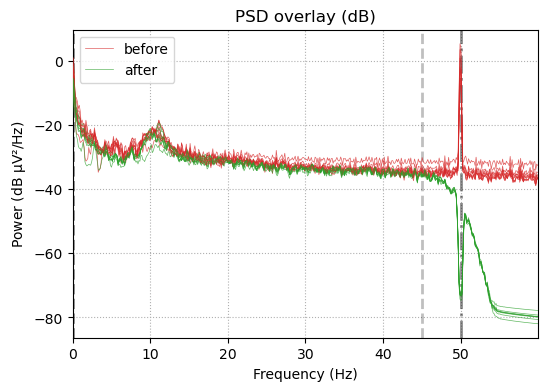

In [23]:
# PSD overlay (before vs. after) for one block

pre_file = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
post_file = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

psd_pre  = raw_pre.compute_psd(fmax=60, picks="eeg")
psd_post = raw_post.compute_psd(fmax=60, picks="eeg")

fig, ax = plt.subplots(figsize=(6, 4))

# --- plot BEFORE ---
psd_pre.plot(axes=ax, color="tab:red",  spatial_colors=False,
             dB=True, show=False)
ax.lines[-1].set_label("before")  # label the thick aggregate line

# --- plot AFTER ---
psd_post.plot(axes=ax, color="tab:green", spatial_colors=False,
              dB=True, show=False)
ax.lines[-1].set_label("after")

ax.legend()
ax.set_title(f"PSD overlay (dB)")
plt.show()


##### Butterfly traces (10 s) — before vs after filtering

This 10-second **butterfly view** overlays all EEG channels to show the effect of linear filtering.

Key points we check here:

* **DC offset and low-frequency drift** have been removed.  
* **No channel is saturated, flat-lined, or artefact-heavy.**  
* High-frequency activity is preserved but cleaner.

Both plots use the **same vertical scale (2 µV/div)** to allow direct visual comparison.  
This view complements the PSD overlay and helps detect residual artefacts that may not show up in the frequency domain.


In [24]:
# Butterfly traces (before vs. after)
pre_file = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
post_file = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

# --- BEFORE filtering ----------------------------------------------------
raw_pre.plot(
    duration=10, start=0, butterfly=True,
    picks="eeg",
    remove_dc=True,                 # subtract mean per channel for display
    scalings=dict(eeg=2e-6),
    title=f"Block {idx:02d} – BEFORE filtering (2 µV/div)"
)

# --- AFTER filtering -----------------------------------------------------
raw_post.plot(
    duration=10, start=0, butterfly=True,
    picks="eeg",
    remove_dc=True,                 # keep baselines centred
    scalings=dict(eeg=2e-6),        # 10 µV/div is common convention
    title=f"Block {idx:02d} – AFTER filtering (2 µV/div)"
)


Using qt as 2D backend.
Using pyopengl with version 3.1.9
Using pyopengl with version 3.1.9


##### Channel-wise browser (10 s) — before vs after filtering

This 10-second **channel-by-channel view** displays all 14 EEG channels using their standard 10–20 positions (Fp1 … P4), each on its own horizontal track.

Unlike the butterfly plot, this layout helps you spot **spatially localized issues**, such as:

* Persistent **DC offsets** or baseline shifts specific to a channel  
* **Flat-lines** (bad electrode contact) or **saturation/clipping** artefacts  
* **Polarity errors** (e.g., inverted traces)  
* High-frequency artefacts affecting only one region  

Both plots are shown with **automatic vertical scaling** (`scalings="auto"`), so each version adapts to its own signal dynamics.  
Use this view to **visually confirm filtering effects** and verify that no channel was lost or distorted in the process.

Scroll and zoom to explore the full trace across time and space.


In [25]:
# trace before vs. after (consistent variable names)
pre_file = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
post_file = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

print("\n=== Traces before filtering (10 s) ===")
raw_pre.plot(
    duration=10, n_channels=len(raw_pre.ch_names),
    scalings="auto"
)

print("\n=== Traces after filtering (10 s) ===")
raw_post.plot(
    duration=10, n_channels=len(raw_post.ch_names),
    scalings="auto"
)



=== Traces before filtering (10 s) ===
Using pyopengl with version 3.1.9

=== Traces after filtering (10 s) ===
Using pyopengl with version 3.1.9


##### Variance topomap — before vs after filtering

The **channel-wise variance** (σ² in µV²) provides a quick spatial overview of signal stability across the scalp.

This visual diagnostic helps detect electrodes that are consistently noisier than the rest — for example:

* **High variance before filtering** may indicate DC drift, mains interference, or poor electrode contact.  
* **After filtering and cropping**, the topomap should become more homogeneous;  
  any electrode that still stands out may need to be rejected or interpolated before ICA.

In this plot:

- We compute the **empirical covariance** matrix for each stage.  
- We extract the **diagonal** to get per-channel variance.  
- Both topomaps use the **same color scale** for direct comparison.

This is especially useful when deciding whether to apply average reference or run ICA.


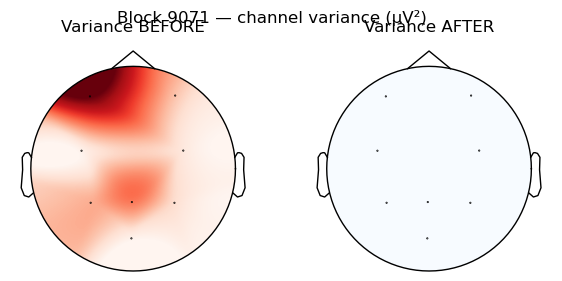

In [26]:
# Variance topomap before vs. after filtering (consistent variable names)
pre_file = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
post_file = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

# keep only EEG; remove DC for fair comparison
raw_pre_eeg  = (raw_pre.copy()
                .pick("eeg")
                .apply_function(lambda x: x - x.mean(-1, keepdims=True)))
raw_post_eeg = (raw_post.copy()
                .pick("eeg")
                .apply_function(lambda x: x - x.mean(-1, keepdims=True)))

# empirical covariance → diagonal elements are variances (µV²)
cov_pre  = mne.compute_raw_covariance(raw_pre_eeg,  method="empirical", verbose=False)
cov_post = mne.compute_raw_covariance(raw_post_eeg, method="empirical", verbose=False)
var_pre  = cov_pre.data.diagonal()
var_post = cov_post.data.diagonal()

# common color scale
vlim = (min(var_pre.min(), var_post.min()),
        max(var_pre.max(), var_post.max()))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

mne.viz.plot_topomap(
    var_pre, raw_pre.info, axes=axes[0],
    cmap="Reds", vlim=vlim, contours=0, sphere=0.09, show=False
)
axes[0].set_title("Variance BEFORE")

mne.viz.plot_topomap(
    var_post, raw_post.info, axes=axes[1],
    cmap="Blues", vlim=vlim, contours=0, sphere=0.09, show=False
)
axes[1].set_title("Variance AFTER")

fig.suptitle(f"Block {idx:02d} — channel variance (µV²)")
plt.show()


### 5d · Check that blinks / artefacts do not saturate  

After correcting the count → Volt scaling, we expect typical peak EEG
amplitudes of **±5–20 µV** in resting state and up to **±100 µV** for eye
blinks.  Anything beyond ±200 µV would indicate possible saturation or a bad
electrode.

* **Visual:** butterfly at **20 µV / div** to make small peaks visible.  
* **Automatic:** peak-finder per block prints the maximum absolute µV; a
  value \< 200 µV is considered OK.


In [27]:
# Automatic peak amplitude scan for the filtered binary block

def peak_uV(raw):
    """Return max absolute amplitude (µV) per EEG channel."""
    data = raw.get_data(picks="eeg") * 1e6  # V → µV
    return np.max(np.abs(data), axis=1)

# Threshold for flagging abnormal peaks
thr = 100  # µV
fpath = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"

# Check and load
if fpath.exists():
    raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
    peaks = peak_uV(raw)
    max_peak = peaks.max()
    flag = "OK" if max_peak <= thr else "⚠️  high"

    print(f"{'Max peak (µV)':<15}: {max_peak:6.1f} µV  →  {flag}")
    print(f"{'Per-channel peaks'}:")
    for ch, val in zip(raw.ch_names, peaks):
        print(f"  {ch:<6} → {val:6.1f} µV")
else:
    print("❌ File not found:", fpath.name)


Max peak (µV)  :    8.1 µV  →  OK
Per-channel peaks:
  F3     →    3.2 µV
  F4     →    1.8 µV
  C3     →    8.1 µV
  C4     →    4.2 µV
  P3     →    4.7 µV
  P4     →    1.5 µV
  Pz     →    1.4 µV
  Oz     →    4.0 µV


## 6. Master report

Click a block in the expandable list to view its full set of QA figures
(PSD, butterfly, variance map).  The HTML is saved alongside the
cleaned `.fif` files for easy sharing.


In [28]:
def butterfly_static(raw, title,
                     scale_uV,            # µV per division
                     n_div=5, dur=10,
                     remove_dc=True):
    """Static butterfly plot with fixed scale."""
    sf = raw.info['sfreq']
    t_stop = int(dur * sf)
    data, times = raw.get_data(picks="eeg", stop=t_stop, return_times=True)
    data *= 1e6                                # V → µV
    if remove_dc:
        data -= data.mean(-1, keepdims=True)

    lim = scale_uV * n_div
    fig, ax = plt.subplots(figsize=(6, 2.5))
    for ch in data:
        ax.plot(times, ch, lw=.4, color="k")

    ax.set_ylim(-lim, lim)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("µV")
    ax.set_title(f"{title}  ({scale_uV} µV/div)")
    ax.grid(ls=":", alpha=.3)
    return fig


In [29]:
def make_report_from_paths(raw_pre_path, raw_post_path, output_html_path):
    """
    Generate QA report from a pair of raw .fif files (pre + post filtering).

    Parameters
    ----------
    raw_pre_path : Path
        Path to unfiltered Raw FIF file (before filtering/cropping).
    raw_post_path : Path
        Path to filtered Raw FIF file (after cropping).
    output_html_path : Path
        Destination path for saving the QA report HTML.
    """
    from mne.viz import plot_topomap
    import matplotlib.pyplot as plt

    raw_pre = mne.io.read_raw_fif(raw_pre_path, preload=True, verbose=False)
    raw_post = mne.io.read_raw_fif(raw_post_path, preload=True, verbose=False)

    # PSD overlay
    fig_psd, ax = plt.subplots(figsize=(6, 3))
    for raw, col, lab in [
        (raw_pre,  "tab:red",   "before"),
        (raw_post, "tab:green", "after")
    ]:
        raw.compute_psd(fmax=60, picks="eeg").plot(
            axes=ax, color=col, spatial_colors=False, dB=True, show=False
        )
        ax.lines[-1].set_label(lab)
    ax.legend(); ax.set_title("PSD overlay (dB)")
    plt.close(fig_psd)

    # Butterfly plots
    fig_bt_pre = butterfly_static(raw_pre, "Butterfly BEFORE", scale_uV=20, remove_dc=False)
    fig_bt_post = butterfly_static(raw_post, "Butterfly AFTER", scale_uV=2, remove_dc=True)
    plt.close(fig_bt_pre); plt.close(fig_bt_post)

    # Channel variance maps
    def var_diag(r):
        r = (r.copy()
               .pick("eeg")
               .apply_function(lambda x: x - x.mean(-1, keepdims=True)))
        cov = mne.compute_raw_covariance(r, method="empirical", verbose=False)
        return cov.data.diagonal()

    var_pre, var_post = var_diag(raw_pre), var_diag(raw_post)
    vlim = (min(var_pre.min(), var_post.min()), max(var_pre.max(), var_post.max()))

    fig_var, axes = plt.subplots(1, 2, figsize=(6, 3))
    plot_topomap(var_pre, raw_pre.info, axes=axes[0],
                 cmap="Reds", vlim=vlim, contours=0,
                 sphere=0.09, show=False)
    axes[0].set_title("Variance BEFORE")

    plot_topomap(var_post, raw_post.info, axes=axes[1],
                 cmap="Blues", vlim=vlim, contours=0,
                 sphere=0.09, show=False)
    axes[1].set_title("Variance AFTER")
    fig_var.suptitle("Channel variance (µV²)")
    plt.close(fig_var)

    # Build and save report
    rep = mne.Report(title="QA sunimagery")
    rep.add_figure(fig_psd,     title="PSD overlay")
    rep.add_figure(fig_bt_pre,  title="Butterfly BEFORE")
    rep.add_figure(fig_bt_post, title="Butterfly AFTER")
    rep.add_figure(fig_var,     title="Channel variance")

    rep.save(output_html_path, overwrite=True, open_browser=False, verbose=False)
    print(f"✔ saved {output_html_path}")
    return rep


In [30]:
raw_pre_path = CONFIG['raw_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_eeg.fif"
raw_post_path = CONFIG['fif_dir'] / "sub-lina_ses-03_task-sunimagery_run-01_desc-filtcrop_eeg.fif"
qa_out_path = CONFIG['qa_dir'] / "qa_sunimagery_run-01.html"

make_report_from_paths(raw_pre_path, raw_post_path, qa_out_path)


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
✔ saved ../bids_dataset/derivatives/qa_reports/sub-lina/ses-03/eeg/qa_sunimagery_run-01.html


<Report | 4 titles | 4 items | QA sunimagery  | 0.1 MB
 PSD overlay                                  | 0.0 MB
 Butterfly BEFORE                             | 0.0 MB
 Butterfly AFTER                              | 0.0 MB
 Channel variance                             | 0.0 MB
>

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none
